In [1]:
#Imports
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from Rotor import Rotor
import multi_rotor_analysis
import plotting_routines
from globals import plot_dir, res_dir, data_dir

U0 = 60
rho  = 1.007
D = 0.7*2

## Convergence History

1036.4773344829946


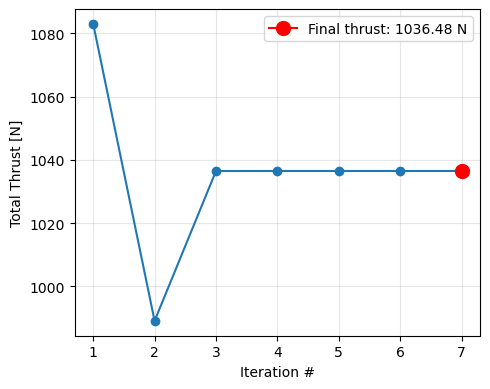

In [2]:
fpath = res_dir.joinpath('CT_hist.csv')

rotor = Rotor(
# Geometry definition
c_R_func  = lambda r_R : 0.18-0.06*r_R,
twst_func = lambda r_R : -50*r_R+35,
pitch = 45,
B     = 6,
R     = 0.7,
r_R_H = 0.25,
polar_path = data_dir.joinpath('ARAD8pct_polar.txt'),
# Operating condition
J = 1.2,
Vinf = 60,
rho = 1.067,
# Discretizaiton
n_elem = 100,
dist_elem = 'uniform',
isPropeller = True)

rotor.export_hist(fpath, vname='CT')

plotting_routines.convergence_history(
    save=True,
    filename=fpath)

## Spanwise Distribution Plots

In [3]:
## FETCHING DATA

# Initialising arrays
J = [1.6, 2, 2.4]
dfs = []

for i, j in enumerate(J):
    # Define rotor & solve BEM
    rotor = Rotor(
        # Geometry definition
        c_R_func  = lambda r_R : 0.18-0.06*r_R,
        twst_func = lambda r_R : -50*r_R+35,
        pitch = 45,
        B     = 6,
        R     = 0.7,
        r_R_H = 0.25,
        polar_path = data_dir.joinpath('ARAD8pct_polar.txt'),
        # Operating condition
        J = j,
        Vinf = 60,
        rho = 1.067,
        # Discretizaiton
        n_elem = 100,
        dist_elem = 'uniform',
        isPropeller = True
        )

    # Define result filename
    fname = res_dir.joinpath(f'span_dist_J_{j:.1f}.csv')
    
    # Export distribution
    rotor.export_dist(fname)

    # Read distribution
    dfs.append(pd.read_csv(fname, sep=r","))   


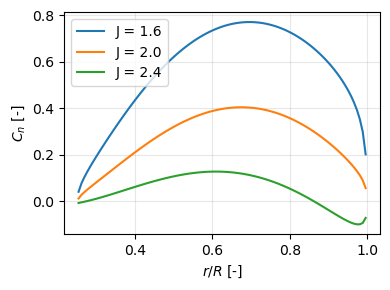

In [4]:
# CX Plot
fig, ax = plt.subplots(figsize=(4,3))

for df, j in zip(dfs, J):
    plotting_routines.distribution('Cx', df, ax, label=f'J = {j:.1f}')

ax.legend()
fig.tight_layout()

fig.savefig(plot_dir.joinpath("span_dist_Cx.pdf"))

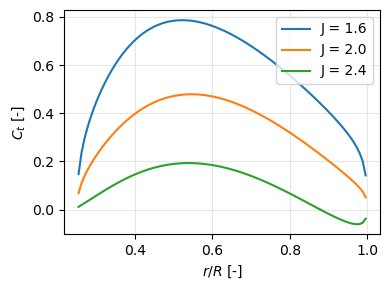

In [5]:
# CY Plot
fig, ax = plt.subplots(figsize=(4,3))

for df, j in zip(dfs, J):
    plotting_routines.distribution('Cy', df, ax, label=f'J = {j:.1f}')

ax.legend()
fig.tight_layout()

fig.savefig(plot_dir.joinpath("span_dist_Cy.pdf"))

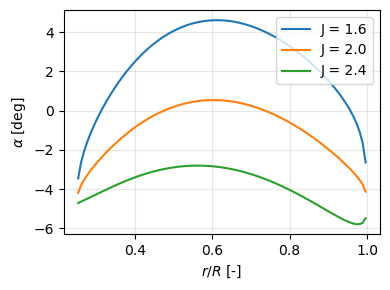

In [6]:
# alpha Plot
fig, ax = plt.subplots(figsize=(4,3))

for df, j in zip(dfs, J):
    plotting_routines.distribution('alpha', df, ax, label=f'J = {j:.1f}')

ax.legend(loc='upper right')
fig.tight_layout()

fig.savefig(plot_dir.joinpath("span_dist_alpha.pdf"))

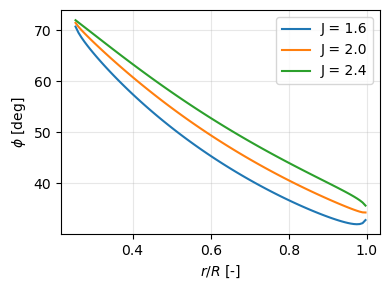

In [7]:
# phi Plot
fig, ax = plt.subplots(figsize=(4,3))

for df, j in zip(dfs, J):
    plotting_routines.distribution('phi', df, ax, label=f'J = {j:.1f}')

ax.legend()
fig.tight_layout()

fig.savefig(plot_dir.joinpath("span_dist_phi.pdf"))

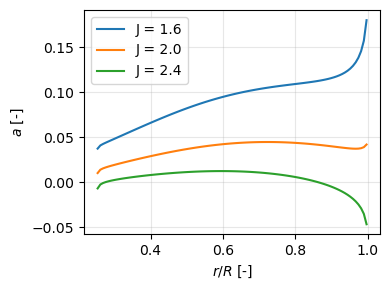

In [8]:
# a Plot
fig, ax = plt.subplots(figsize=(4,3))

for df, j in zip(dfs, J):
    plotting_routines.distribution('a', df, ax, label=f'J = {j:.1f}')

ax.legend()
fig.tight_layout()

fig.savefig(plot_dir.joinpath("span_dist_a.pdf"))

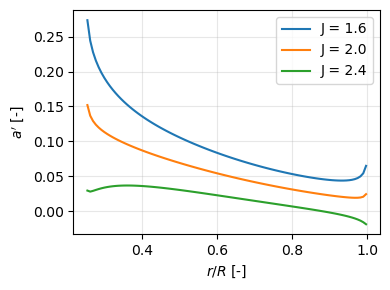

In [9]:
# a Plot
fig, ax = plt.subplots(figsize=(4,3))

for df, j in zip(dfs, J):
    plotting_routines.distribution('aline', df, ax, label=f'J = {j:.1f}')

ax.legend()
fig.tight_layout()

fig.savefig(plot_dir.joinpath("span_dist_aline.pdf"))

## Varying J Plot

In [10]:
# Generating Data
fpath = multi_rotor_analysis.run('J', 'main', 'results')
dfJ = pd.read_csv(fpath)


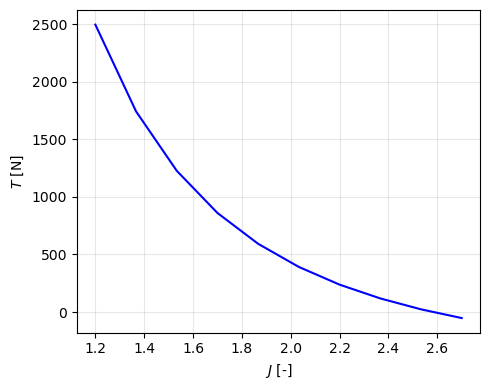

In [11]:
# Thrust Plot
fig, ax = plt.subplots(figsize=(5,4))

plotting_routines.forces(plot_vs='J',
                         plot_ag='T',
                         data_df=dfJ,                
                         ax=ax,
                         color='blue')

fig.tight_layout()

fig.savefig(plot_dir.joinpath("T_vary_J.pdf"))


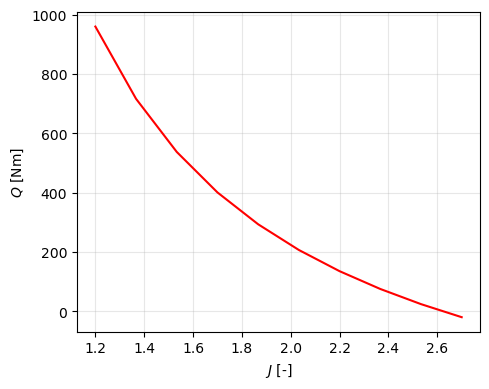

In [12]:
# Torque Plot
fig, ax = plt.subplots(figsize=(5,4))

plotting_routines.forces(plot_vs='J',
                         plot_ag='Q',                         
                         data_df=dfJ,                
                         ax=ax,
                         color='red')

fig.tight_layout()

fig.savefig(plot_dir.joinpath("Q_vary_J.pdf"))

## Varying n Plot

In [13]:
# Generating Data
fpath = multi_rotor_analysis.run('n', 'main', 'results')
dfn = pd.read_csv(fpath)

d:\OneDrive - Delft University of Technology\04 Fourth Year\AE4135 - Rotor Wake Aerodynamics\RWA_assignments\1_BEM\Rotor.py:123: RuntimeWarning: invalid value encountered in scalar divide
  self.eta = self.TC/self.PC


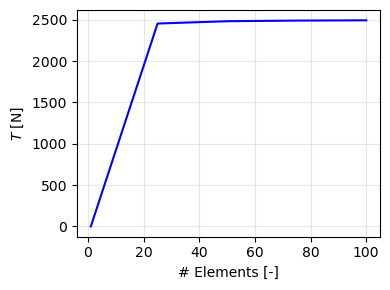

In [14]:
# Thrust Plot
fig, ax = plt.subplots(figsize=(4,3))

plotting_routines.forces(plot_vs='n_elem',
                         plot_ag='T',
                         data_df=dfn,                
                         ax=ax,
                         color='blue')

fig.tight_layout()
fig.savefig(plot_dir.joinpath("T_vary_nelem.pdf"))

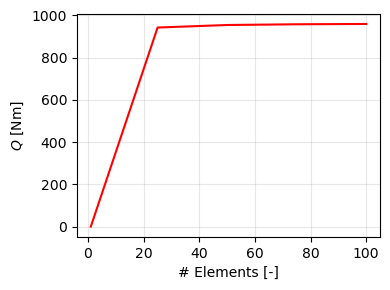

In [15]:
# Thrust Plot
fig, ax = plt.subplots(figsize=(4,3))

plotting_routines.forces(plot_vs='n_elem',
                         plot_ag='Q',
                         data_df=dfn,                
                         ax=ax,
                         color='red')

fig.tight_layout()
fig.savefig(plot_dir.joinpath("Q_vary_nelem.pdf"))